In [1]:
%load_ext autoreload
%autoreload 2

from pathlib import Path

import diffrax
import jax
import jax.numpy as jnp
import matplotlib.pyplot as plt
import numpy as np
import torch
from rich import print

from pymcsimmod import model
from pymcsimmod.parser import ModelParser

from pymcsimmod import JaxModel, ScipyModel, TorchModel

In [2]:
filename = Path("../../tests/data/pk1.model")
assert filename.exists()
print(filename.absolute().resolve())

C:\Users\ASHAPIRO\dev\PyMCSimMod\tests\data\pk1.model

In [3]:
parser = ModelParser()
parsed_model = parser.parse(filename.read_text())

# Run Scipy model

<Axes: xlabel='Time', ylabel='Value'>

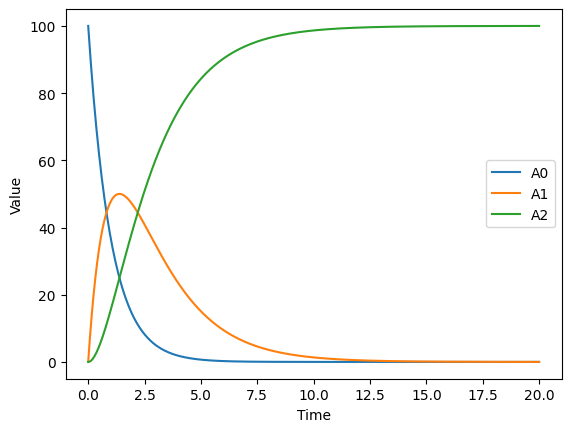

In [4]:
scipy_model = ScipyModel(model=filename)
times = np.linspace(0, 20, 500)
solution = scipy_model.run_model(times)
solution.plot_results(variables=["A0", "A1", "A2"])

<Axes: xlabel='Time', ylabel='Value'>

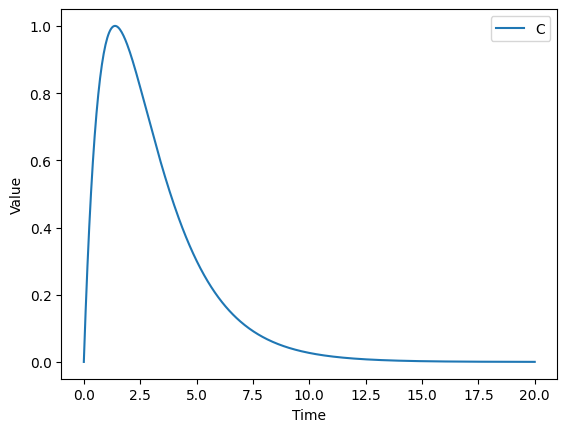

In [5]:
solution.plot_results(variables="C")

# Run Jax model

<Axes: xlabel='Time', ylabel='Value'>

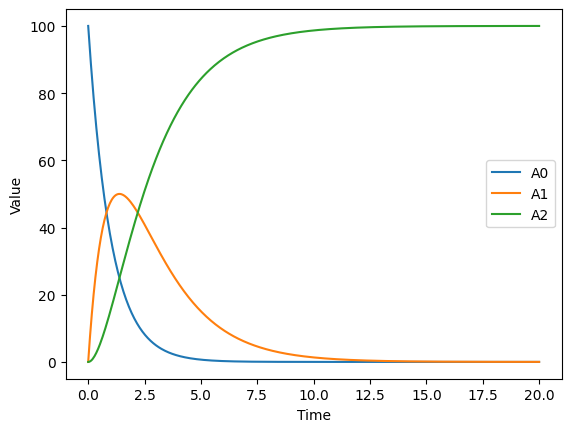

In [6]:
jax_model = JaxModel(model=filename)
times = np.linspace(0, 20, 500)
solution = jax_model.run_model(times)
solution.plot_results(variables=["A0", "A1", "A2"])

<Axes: xlabel='Time', ylabel='Value'>

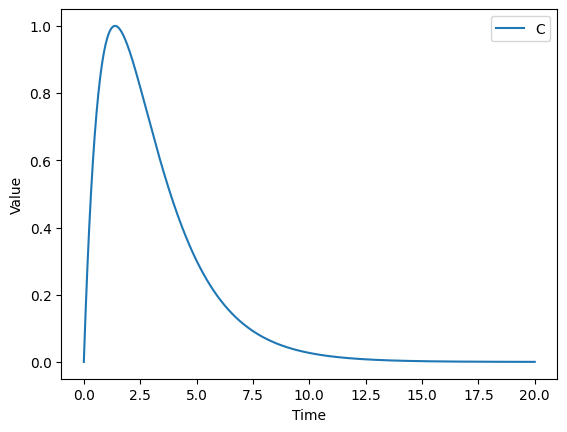

In [7]:
solution.plot_results(variables="C")

## Run Torch model

<Axes: xlabel='Time', ylabel='Value'>

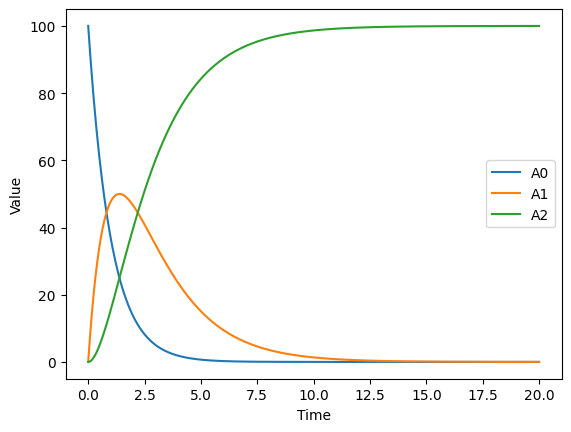

In [8]:
torch_model = TorchModel(model=filename)
times = torch.linspace(0.0, 20.0, steps=500)
torch_model.update_Y0(A0=100.0, A1=0.0, A2=0.0, AUC=0.0)
solution = torch_model.run_model(times)
solution.plot_results(variables=["A0", "A1", "A2"])

<Axes: xlabel='Time', ylabel='Value'>

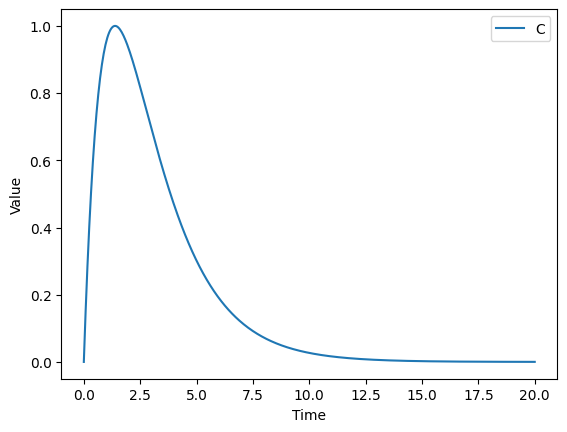

In [9]:
solution.plot_results(variables="C")